<a href="https://colab.research.google.com/github/MeLBiN122/AI-ML/blob/main/T1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler

In [3]:
df = pd.read_csv('/content/preprocessing_practice_dataset.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         100 non-null    int64  
 1   Age                 90 non-null     float64
 2   Gender              100 non-null    object 
 3   Department          90 non-null     object 
 4   Education           90 non-null     object 
 5   Experience_Years    100 non-null    int64  
 6   Monthly_Salary      90 non-null     float64
 7   Performance_Rating  100 non-null    int64  
 8   City                90 non-null     object 
 9   Attrition           100 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 7.9+ KB


In [8]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [17]:
df['Department_mode_imputed'] = df['Department'].fillna(df['Department'].mode()[0])
df['Education_mode_imputed'] = df['Education'].fillna(df['Education'].mode()[0])
df['City_mode_imputed'] = df['City'].fillna(df['City'].mode()[0])
df['Age_mean_imputed'] = df['Age'].fillna(df['Age'].mean())
df['Monthly_Salary_mean_imputed'] = df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean())

In [19]:
df[['City','City_mode_imputed']]

,City,City_mode_imputed
0,Calicut,Calicut
1,Chennai,Chennai
2,Kochi,Kochi
3,Trivandrum,Trivandrum
4,Trivandrum,Trivandrum
...,...,...
95,Chennai,Chennai
96,Trivandrum,Trivandrum
97,Chennai,Chennai
98,Calicut,Calicut


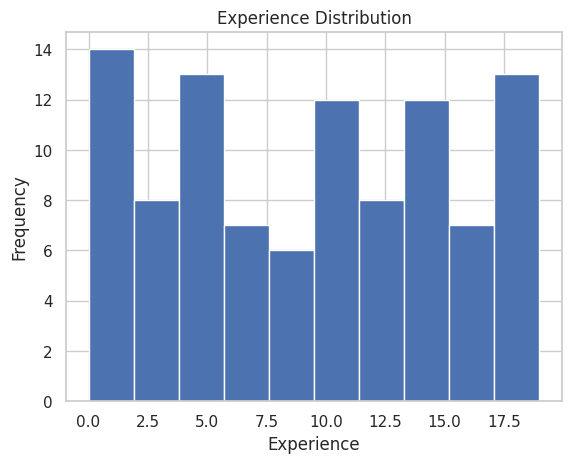

In [22]:
plt.hist(df['Experience_Years'].dropna(), bins=10)
plt.title('Experience Distribution')
plt.xlabel('Experience')
plt.ylabel('Frequency')
plt.show()

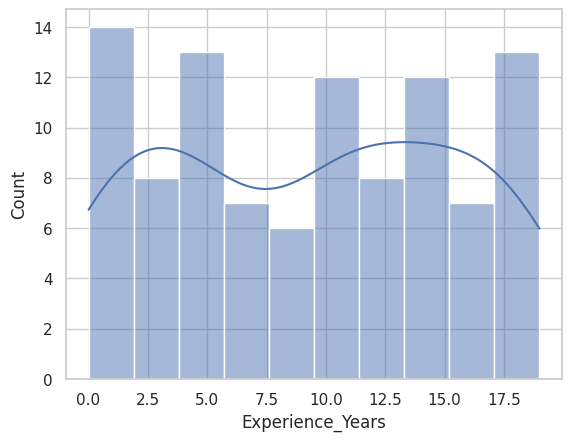

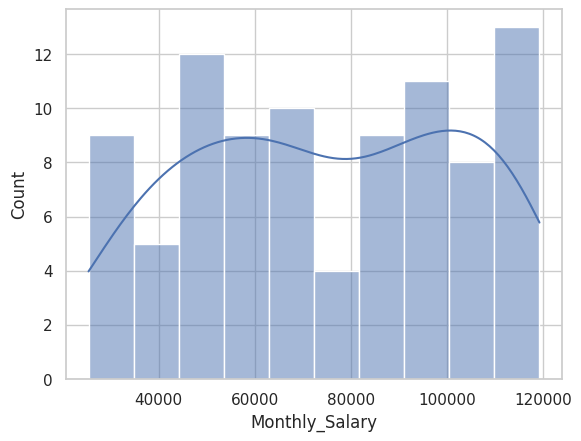

In [24]:
sns.histplot(df['Experience_Years'], bins=10, kde=True)
plt.show()

sns.histplot(df['Monthly_Salary'], bins=10, kde=True)
plt.show()

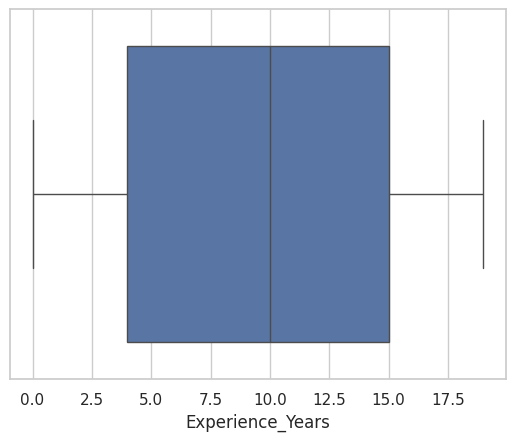

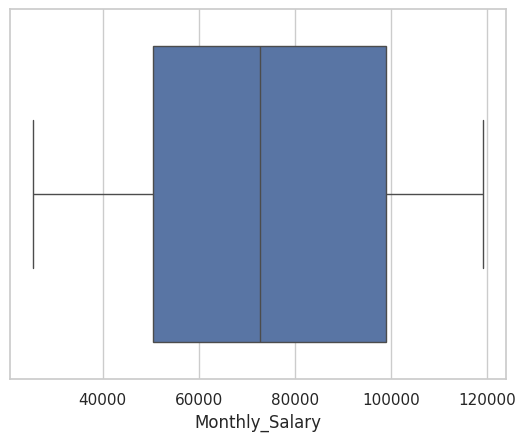

In [27]:
sns.boxplot(x=df['Experience_Years'])
plt.show()

sns.boxplot(x=df['Monthly_Salary'])
plt.show()

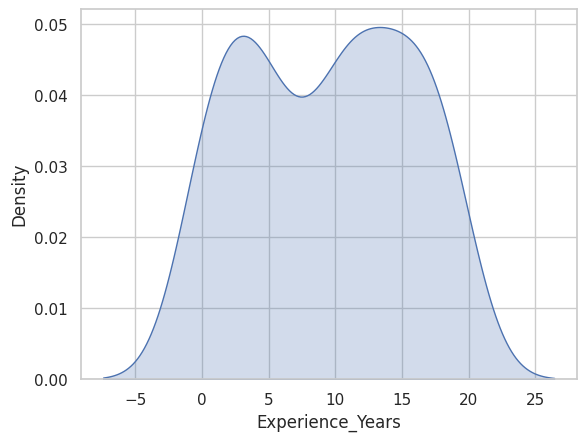

In [29]:
sns.kdeplot(df['Experience_Years'], fill=True)
plt.show()

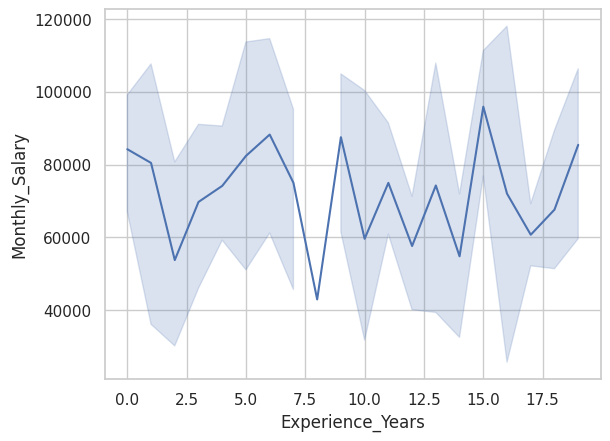

In [30]:
sns.lineplot(x='Experience_Years', y='Monthly_Salary', data=df)
plt.show()

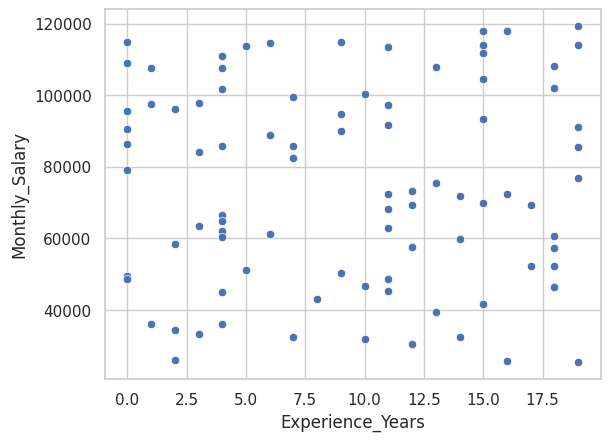

In [31]:
sns.scatterplot(x='Experience_Years', y='Monthly_Salary', data=df)
plt.show()

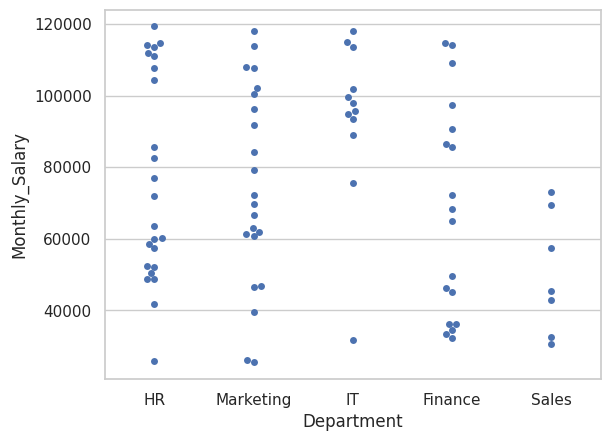

In [32]:
sns.swarmplot(x='Department', y='Monthly_Salary', data=df)
plt.show()

In [38]:
label_encoder = LabelEncoder()
df['Gender_Encoded'] = label_encoder.fit_transform(df['Gender'])
one_hot_encoded = pd.get_dummies(
    df[['Department_mode_imputed',
        'Education_mode_imputed',
        'City_mode_imputed']],
    prefix=['Department', 'Education', 'City']
)
df = pd.concat([df, one_hot_encoded], axis=1)

In [42]:
df['Gender_Encoded']


,Gender_Encoded
0,1
1,0
2,0
3,0
4,1
...,...
95,0
96,1
97,1
98,0


In [43]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Employee_ID                  100 non-null    int64  
 1   Age                          90 non-null     float64
 2   Gender                       100 non-null    object 
 3   Department                   90 non-null     object 
 4   Education                    90 non-null     object 
 5   Experience_Years             100 non-null    int64  
 6   Monthly_Salary               90 non-null     float64
 7   Performance_Rating           100 non-null    int64  
 8   City                         90 non-null     object 
 9   Attrition                    100 non-null    int64  
 10  Age_mean_imputed             100 non-null    float64
 11  Department_mode_imputed      100 non-null    object 
 12  Education_mode_imputed       100 non-null    object 
 13  City_mode_imputed    

In [44]:
minmax_scaler = MinMaxScaler()

df[['Age_mean_imputed',
    'Experience_Years',
    'Monthly_Salary_mean_imputed',
    'Performance_Rating']] = minmax_scaler.fit_transform(
        df[['Age_mean_imputed','Experience_Years','Monthly_Salary_mean_imputed','Performance_Rating']])

In [45]:
standard_scaler = StandardScaler()

df[['Age_mean_imputed',
    'Experience_Years',
    'Monthly_Salary_mean_imputed',
    'Performance_Rating']] = standard_scaler.fit_transform(
    df[['Age_mean_imputed','Experience_Years','Monthly_Salary_mean_imputed','Performance_Rating']])

In [46]:
df.head()

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition,...,Department_Marketing,Department_Sales,Education_Bachelors,Education_Masters,Education_PhD,City_Bangalore,City_Calicut,City_Chennai,City_Kochi,City_Trivandrum
0,1001,59.0,Male,HR,Masters,1.398095,52350.0,1.205142,Calicut,0,...,False,False,False,True,False,False,True,False,False,False
1,1002,49.0,Female,Marketing,Bachelors,1.074462,118008.0,-0.837471,Chennai,1,...,True,False,True,False,False,False,False,True,False,False
2,1003,35.0,Female,HR,NaN,1.559911,119297.0,-1.518342,Kochi,1,...,False,False,False,True,False,False,False,False,True,False
3,1004,28.0,Female,HR,PhD,-0.058254,50351.0,-0.837471,Trivandrum,1,...,False,False,False,False,True,False,False,False,False,True
4,1005,41.0,Male,IT,Bachelors,-0.705520,113668.0,-0.156600,Trivandrum,1,...,False,False,True,False,False,False,False,False,False,True


In [47]:
df[['Age_mean_imputed','Experience_Years','Monthly_Salary_mean_imputed','Performance_Rating']].head()

,Age_mean_imputed,Experience_Years,Monthly_Salary_mean_imputed,Performance_Rating
0,1.841242,1.398095,-0.859586,1.205142
1,0.878921,1.074462,1.619930,-0.837471
2,-0.468330,1.559911,1.668607,-1.518342
3,-1.141955,-0.058254,-0.935077,-0.837471
4,0.109063,-0.705520,1.456033,-0.156600
